In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [3]:
df=pd.read_csv("C:/Users/deyom/Downloads/synthetic_customer_churn_100k.csv")

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [6]:
df.drop('CustomerID',axis=1,inplace=True)

In [7]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1,'Other':2})

In [8]:
df['Contract'].unique()

array(['Two year', 'Month-to-month', 'One year'], dtype=object)

In [9]:
df = pd.get_dummies(
    df,
    columns=['Contract'],
    drop_first=True
)

In [10]:
df['PaymentMethod'].unique()

array(['Bank transfer', 'Mailed check', 'Electronic check', 'Credit card'],
      dtype=object)

In [11]:
df['PaymentMethod']=df['PaymentMethod'].map({'Bank transfer':0,'Mailed check':1,'Electronic check':2,'Credit card':3})

In [12]:
df['Churn']=df['Churn'].map({'No':0,'Yes':1})

In [13]:
df.corr()

,Age,Gender,Tenure,MonthlyCharges,PaymentMethod,TotalCharges,Churn,Contract_One year,Contract_Two year
Age,1.000000,0.000059,0.007915,0.004835,-0.004241,0.008958,-0.005875,0.005572,0.001864
Gender,0.000059,1.000000,-0.003602,-0.002325,0.001299,-0.003356,-0.003277,-0.000852,-0.000446
Tenure,0.007915,-0.003602,1.000000,0.005976,-0.004372,0.700959,-0.190924,0.001349,-0.000548
MonthlyCharges,0.004835,-0.002325,0.005976,1.000000,-0.005939,0.623864,0.250055,0.001276,-0.001853
PaymentMethod,-0.004241,0.001299,-0.004372,-0.005939,1.000000,-0.003660,-0.001302,-0.000947,-0.003293
TotalCharges,0.008958,-0.003356,0.700959,0.623864,-0.003660,1.000000,0.023860,0.001254,-0.002776
Churn,-0.005875,-0.003277,-0.190924,0.250055,-0.001302,0.023860,1.000000,-0.202482,-0.171817
Contract_One year,0.005572,-0.000852,0.001349,0.001276,-0.000947,0.001254,-0.202482,1.000000,-0.289085
Contract_Two year,0.001864,-0.000446,-0.000548,-0.001853,-0.003293,-0.002776,-0.171817,-0.289085,1.000000


In [14]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    66.856
1    33.144
Name: proportion, dtype: float64

In [15]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    72.845838
1    94.355298
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='Churn', ylabel='Tenure'>

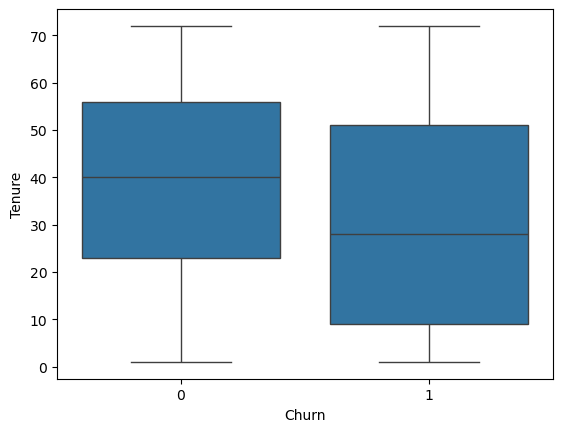

In [16]:
sns.boxplot(x='Churn', y='Tenure', data=df)

In [17]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,0,1
PaymentMethod,,
0,13302,6553
1,16814,8407
2,23277,11615
3,13463,6569


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

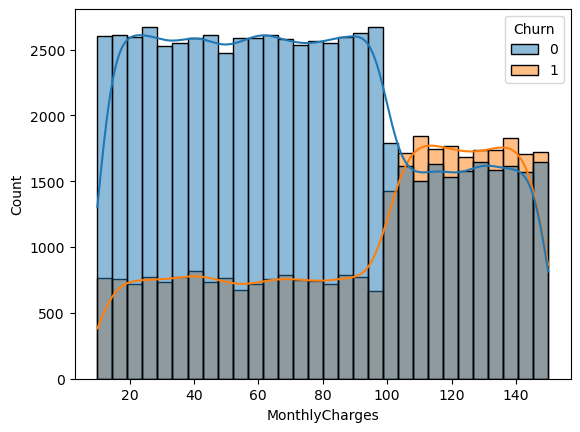

In [18]:
sns.histplot(data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=30,
    kde=True)

<Axes: xlabel='Tenure', ylabel='Count'>

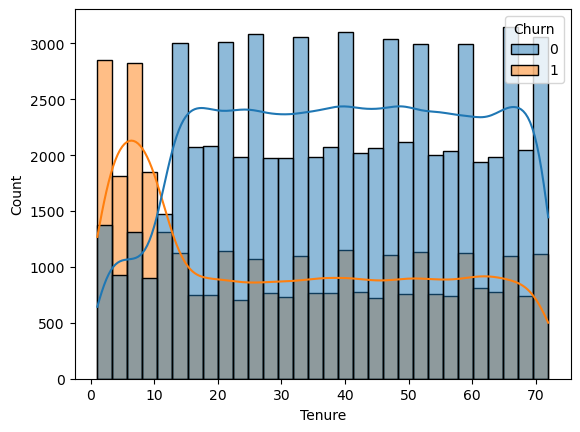

In [19]:
sns.histplot(data=df,
    x='Tenure',
    hue='Churn',
    bins=30,
    kde=True)

In [20]:
df.drop('Age',axis=1,inplace=True)
df.drop('Gender',axis=1,inplace=True)

In [21]:
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Regular', 'Loyal', 'Very Loyal']
)
print(df[['Tenure', 'TenureGroup']].head())

   Tenure TenureGroup
0      68  Very Loyal
1      32       Loyal
2      10         New
3      22     Regular
4      54  Very Loyal


In [22]:
pd.crosstab(df['TenureGroup'], df['Churn'])

Churn,0,1
TenureGroup,,
New,5992,10655
Regular,12166,4471
Loyal,24380,8952
Very Loyal,24318,9066


<Axes: xlabel='TenureGroup', ylabel='count'>

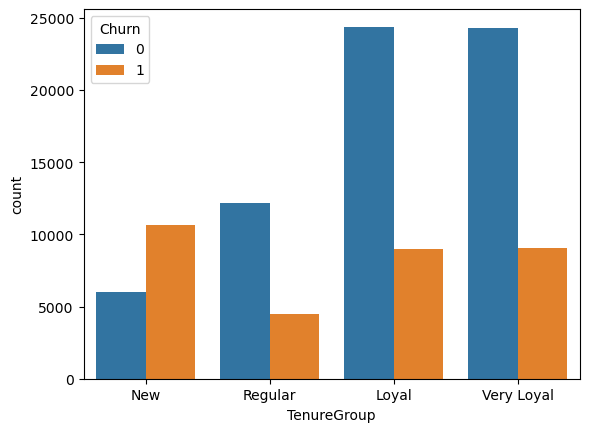

In [23]:
sns.countplot(
    data=df,
    x='TenureGroup',
    hue='Churn'
)

In [24]:
df['TenureGroup'] = df['TenureGroup'].map({
    'New': 0,
    'Regular': 1,
    'Loyal': 2,
    'Very Loyal': 3})

In [25]:
df['AvgMonthlySpend'] = (
    df['TotalCharges'] / (df['Tenure'] + 1)
)

In [26]:
df.head()

,Tenure,MonthlyCharges,PaymentMethod,TotalCharges,Churn,Contract_One year,Contract_Two year,TenureGroup,AvgMonthlySpend
0,68,147.58,0,10052.03,0,False,True,3,145.681594
1,32,22.54,1,686.78,0,False,False,2,20.811515
2,10,52.47,2,537.88,0,True,False,0,48.898182
3,22,109.67,1,2390.04,1,False,False,1,103.914783
4,54,130.98,3,7081.28,0,False,False,3,128.750545


<Axes: xlabel='Churn', ylabel='AvgMonthlySpend'>

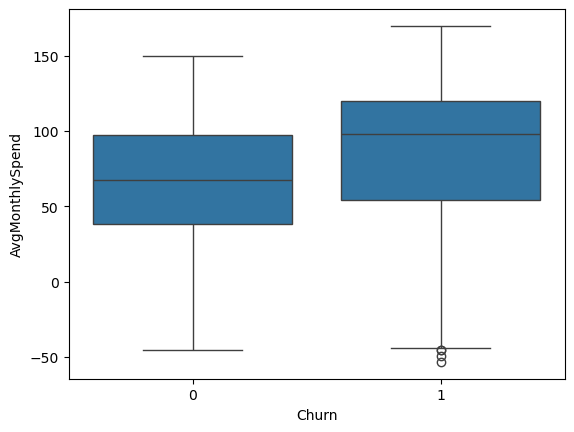

In [27]:
sns.boxplot(
    data=df,
    x='Churn',
    y='AvgMonthlySpend'
)

In [28]:
df.corr()

,Tenure,MonthlyCharges,PaymentMethod,TotalCharges,Churn,Contract_One year,Contract_Two year,TenureGroup,AvgMonthlySpend
Tenure,1.000000,0.005976,-0.004372,0.700959,-0.190924,0.001349,-0.000548,0.946822,0.105306
MonthlyCharges,0.005976,1.000000,-0.005939,0.623864,0.250055,0.001276,-0.001853,0.006296,0.977391
PaymentMethod,-0.004372,-0.005939,1.000000,-0.003660,-0.001302,-0.000947,-0.003293,-0.004569,-0.005643
TotalCharges,0.700959,0.623864,-0.003660,1.000000,0.023860,0.001254,-0.002776,0.663494,0.698514
Churn,-0.190924,0.250055,-0.001302,0.023860,1.000000,-0.202482,-0.171817,-0.223577,0.208269
Contract_One year,0.001349,0.001276,-0.000947,0.001254,-0.202482,1.000000,-0.289085,0.000667,0.001277
Contract_Two year,-0.000548,-0.001853,-0.003293,-0.002776,-0.171817,-0.289085,1.000000,-0.000605,-0.002092
TenureGroup,0.946822,0.006296,-0.004569,0.663494,-0.223577,0.000667,-0.000605,1.000000,0.110696
AvgMonthlySpend,0.105306,0.977391,-0.005643,0.698514,0.208269,0.001277,-0.002092,0.110696,1.000000


In [29]:
dff=df

In [30]:
dff.drop('TenureGroup',axis=1,inplace=True)
dff.drop('AvgMonthlySpend',axis=1,inplace=True)
dff.drop('PaymentMethod',axis=1,inplace=True)

In [31]:
dff.head()

,Tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year
0,68,147.58,10052.03,0,False,True
1,32,22.54,686.78,0,False,False
2,10,52.47,537.88,0,True,False
3,22,109.67,2390.04,1,False,False
4,54,130.98,7081.28,0,False,False


In [32]:
X = dff.drop('Churn', axis=1)
y = dff['Churn']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    stratify=y,
    random_state=42
)

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [36]:
y_pred = model.predict(X_test_scaled)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6906969696969697


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.68      0.75     22062
           1       0.52      0.70      0.60     10938

    accuracy                           0.69     33000
   macro avg       0.67      0.69      0.67     33000
weighted avg       0.72      0.69      0.70     33000



In [39]:
print(confusion_matrix(y_test, y_pred))

[[15084  6978]
 [ 3229  7709]]


In [40]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7726342336916198


In [41]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(importance.sort_values(by='Coefficient', ascending=False))

             Feature  Coefficient
1     MonthlyCharges     0.506240
2       TotalCharges     0.281786
4  Contract_Two year    -0.682618
0             Tenure    -0.716983
3  Contract_One year    -0.747091
